# 🧠 Clustering Algorithms: K-Means & DBSCAN
## A Comprehensive Student Workbook

---

**Course:** Unsupervised Machine Learning  
**Topics:** K-Means Clustering, DBSCAN, Evaluation Metrics, Hyperparameter Tuning  
**Estimated Time:** 3–4 hours  

---

### 📋 What You Will Learn
By the end of this workbook, you will be able to:
- Understand the intuition and math behind K-Means and DBSCAN
- Implement both algorithms from scratch and using scikit-learn
- Evaluate clustering quality using appropriate metrics
- Choose the right algorithm for a given dataset
- Tune hyperparameters effectively

### 📦 Prerequisites
- Python basics (lists, loops, functions)
- NumPy and Matplotlib familiarity
- Basic statistics (mean, distance)

---

## 📦 Section 0: Setup & Imports
Run this cell first. It installs and imports all required libraries.

In [1]:
# Install required packages (uncomment if needed)
# !pip install numpy matplotlib scikit-learn seaborn pandas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, adjusted_rand_score,
    calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')

print('✅ All libraries imported successfully!')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')

✅ All libraries imported successfully!
NumPy version: 1.26.4
Pandas version: 2.1.4


---
# PART 1: K-MEANS CLUSTERING
---

## 📖 1.1 Theory & Intuition

K-Means is a **centroid-based** clustering algorithm. The goal is to partition `n` data points into `k` clusters such that each point belongs to the cluster with the **nearest mean (centroid)**.

### The Objective Function (Inertia)
K-Means minimizes the **Within-Cluster Sum of Squares (WCSS)**:

$$J = \sum_{i=1}^{k} \sum_{x \in C_i} \| x - \mu_i \|^2$$

Where:
- $k$ = number of clusters
- $C_i$ = set of points in cluster $i$
- $\mu_i$ = centroid (mean) of cluster $i$
- $\| x - \mu_i \|^2$ = squared Euclidean distance

### The Algorithm (Lloyd's Algorithm)

```
1. Initialize k centroids randomly
2. REPEAT until convergence:
   a. ASSIGNMENT: Assign each point to the nearest centroid
   b. UPDATE: Recalculate centroids as the mean of assigned points
3. STOP when assignments don't change
```

### ⚠️ Key Assumptions
- Clusters are **spherical** (convex) in shape
- Clusters have **similar sizes**
- You must know `k` in advance
- Sensitive to **outliers** and **initialization**

## 🛠️ 1.2 K-Means from Scratch

Before using scikit-learn, let's implement K-Means ourselves to understand every step.

In [2]:
class KMeansScratch:
    """
    K-Means Clustering implemented from scratch.
    
    Parameters
    ----------
    k : int
        Number of clusters
    max_iters : int
        Maximum iterations before stopping
    tol : float
        Convergence tolerance (centroid movement threshold)
    """
    
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        self.labels = None
        self.inertia_history = []
    
    def _initialize_centroids(self, X):
        """Randomly pick k points as initial centroids."""
        indices = np.random.choice(len(X), self.k, replace=False)
        return X[indices].copy()
    
    def _euclidean_distance(self, a, b):
        """Compute Euclidean distance between two points."""
        return np.sqrt(np.sum((a - b) ** 2))
    
    def _assign_clusters(self, X):
        """Assign each point to the nearest centroid."""
        labels = []
        for point in X:
            distances = [self._euclidean_distance(point, c) for c in self.centroids]
            labels.append(np.argmin(distances))
        return np.array(labels)
    
    def _update_centroids(self, X, labels):
        """Recompute centroids as mean of assigned points."""
        new_centroids = []
        for i in range(self.k):
            cluster_points = X[labels == i]
            if len(cluster_points) == 0:
                # Handle empty cluster: reinitialize randomly
                new_centroids.append(X[np.random.randint(len(X))])
            else:
                new_centroids.append(cluster_points.mean(axis=0))
        return np.array(new_centroids)
    
    def _compute_inertia(self, X, labels):
        """Calculate WCSS (Within-Cluster Sum of Squares)."""
        inertia = 0
        for i in range(self.k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                inertia += np.sum((cluster_points - self.centroids[i]) ** 2)
        return inertia
    
    def fit(self, X):
        """Fit K-Means to data X."""
        # Step 1: Initialize centroids
        self.centroids = self._initialize_centroids(X)
        
        for iteration in range(self.max_iters):
            # Step 2a: Assign clusters
            labels = self._assign_clusters(X)
            
            # Track inertia
            inertia = self._compute_inertia(X, labels)
            self.inertia_history.append(inertia)
            
            # Step 2b: Update centroids
            new_centroids = self._update_centroids(X, labels)
            
            # Check convergence
            centroid_shift = np.max([self._euclidean_distance(old, new) 
                                     for old, new in zip(self.centroids, new_centroids)])
            
            self.centroids = new_centroids
            self.labels = labels
            
            if centroid_shift < self.tol:
                print(f'  ✅ Converged at iteration {iteration + 1}')
                break
        
        self.inertia_ = self.inertia_history[-1]
        return self
    
    def predict(self, X):
        """Predict cluster for new points."""
        return self._assign_clusters(X)

print('✅ KMeansScratch class defined!')

✅ KMeansScratch class defined!


Running K-Means from scratch...
  ✅ Converged at iteration 7


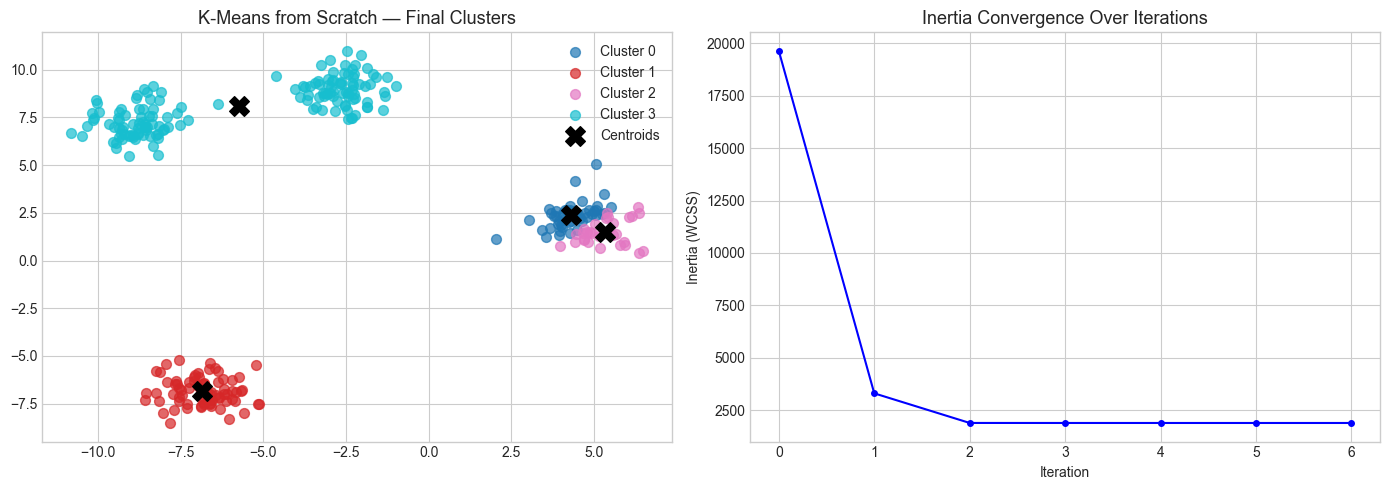

Final Inertia: 1886.1648


In [3]:
# Generate a simple dataset to test our implementation
X_simple, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

# Fit our custom K-Means
print('Running K-Means from scratch...')
km_scratch = KMeansScratch(k=4, max_iters=100)
km_scratch.fit(X_simple)

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot clustering result
colors = plt.cm.tab10(np.linspace(0, 1, 4))
for i in range(4):
    mask = km_scratch.labels == i
    axes[0].scatter(X_simple[mask, 0], X_simple[mask, 1], 
                    c=[colors[i]], label=f'Cluster {i}', alpha=0.7, s=50)
axes[0].scatter(km_scratch.centroids[:, 0], km_scratch.centroids[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[0].set_title('K-Means from Scratch — Final Clusters', fontsize=13)
axes[0].legend()

# Plot inertia over iterations
axes[1].plot(km_scratch.inertia_history, 'b-o', markersize=4)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Inertia (WCSS)')
axes[1].set_title('Inertia Convergence Over Iterations', fontsize=13)

plt.tight_layout()
plt.show()

print(f'Final Inertia: {km_scratch.inertia_:.4f}')

## ✏️ Exercise 1.1 — Modify the Scratch Implementation

**Task:** The current implementation uses random initialization. A better method is **K-Means++** which spreads initial centroids apart.

**K-Means++ Initialization:**
1. Pick the first centroid randomly from data points
2. For each subsequent centroid:
   - Compute distance from each point to its nearest existing centroid
   - Pick next centroid with probability proportional to distance²

**Your Task:** Fill in the `_initialize_centroids_plusplus` method below and compare convergence speed with random initialization.

In [4]:
def _initialize_centroids_plusplus(X, k):
    """
    K-Means++ initialization.
    
    TODO: Implement K-Means++ centroid initialization.
    
    Steps:
    1. Choose first centroid randomly from X
    2. For each of the remaining (k-1) centroids:
       a. For each point, find its minimum distance to existing centroids
       b. Square those distances to get weights
       c. Sample next centroid with probability proportional to weights
    3. Return array of k centroids
    """
    centroids = []
    
    # Step 1: Pick first centroid randomly
    # YOUR CODE HERE
    
    for _ in range(k - 1):
        # Step 2a: Compute distance of each point to nearest centroid
        # YOUR CODE HERE
        
        # Step 2b: Square distances for probability weights
        # YOUR CODE HERE
        
        # Step 2c: Sample next centroid
        # Hint: use np.random.choice with p=probabilities
        # YOUR CODE HERE
        pass
    
    return np.array(centroids)

# Test your implementation here
# centroids = _initialize_centroids_plusplus(X_simple, k=4)
# print('Initial centroids shape:', centroids.shape)

## 🔬 1.3 Visualizing the K-Means Algorithm Step by Step

Let's watch K-Means converge iteration by iteration.

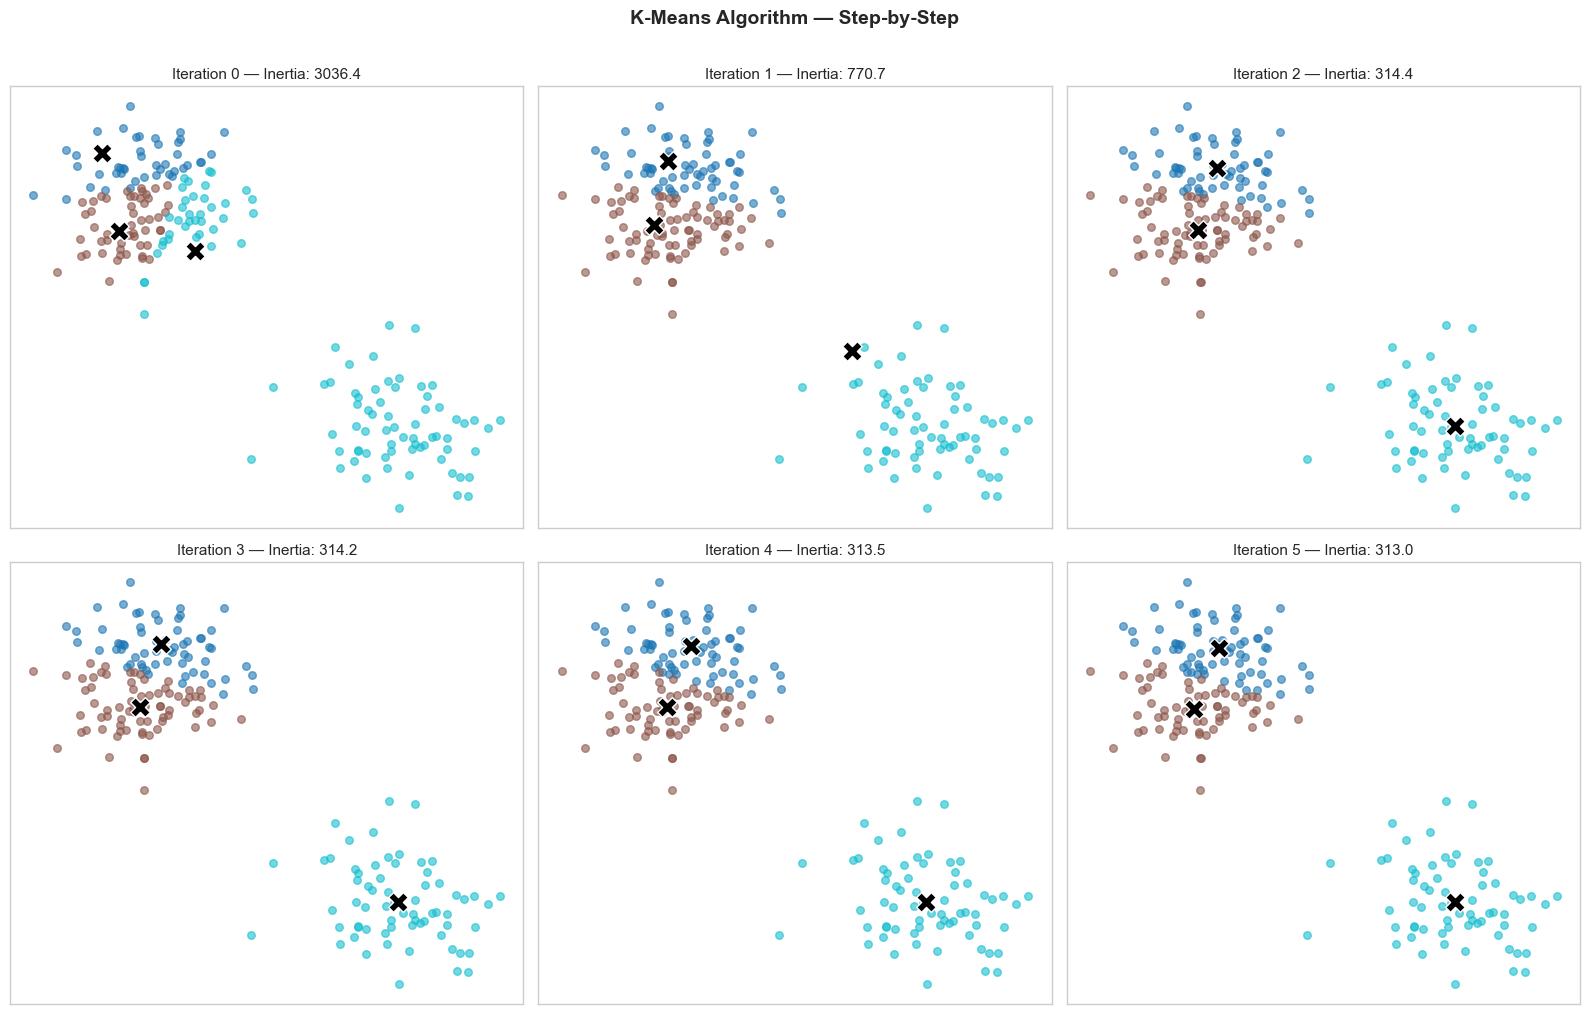

In [5]:
def visualize_kmeans_steps(X, k=3, n_steps=6):
    """Visualize K-Means iterations step by step."""
    np.random.seed(10)
    centroids = X[np.random.choice(len(X), k, replace=False)].copy()
    colors_map = plt.cm.tab10(np.linspace(0, 1, k))
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for step in range(n_steps):
        ax = axes[step]
        
        # Assign clusters
        dists = np.array([[np.linalg.norm(x - c) for c in centroids] for x in X])
        labels = np.argmin(dists, axis=1)
        
        # Plot points
        for i in range(k):
            mask = labels == i
            ax.scatter(X[mask, 0], X[mask, 1], c=[colors_map[i]], alpha=0.6, s=30)
        
        # Plot centroids
        ax.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', 
                   s=200, zorder=10, edgecolors='white', linewidths=1)
        
        inertia = sum(np.min(dists, axis=1)**2)
        ax.set_title(f'Iteration {step} — Inertia: {inertia:.1f}', fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
        
        # Update centroids
        for i in range(k):
            pts = X[labels == i]
            if len(pts) > 0:
                centroids[i] = pts.mean(axis=0)
    
    plt.suptitle('K-Means Algorithm — Step-by-Step', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# Generate data and visualize
X_vis, _ = make_blobs(n_samples=200, centers=3, cluster_std=1.0, random_state=5)
visualize_kmeans_steps(X_vis, k=3, n_steps=6)

## 📐 1.4 Finding Optimal K — The Elbow Method & Silhouette Analysis

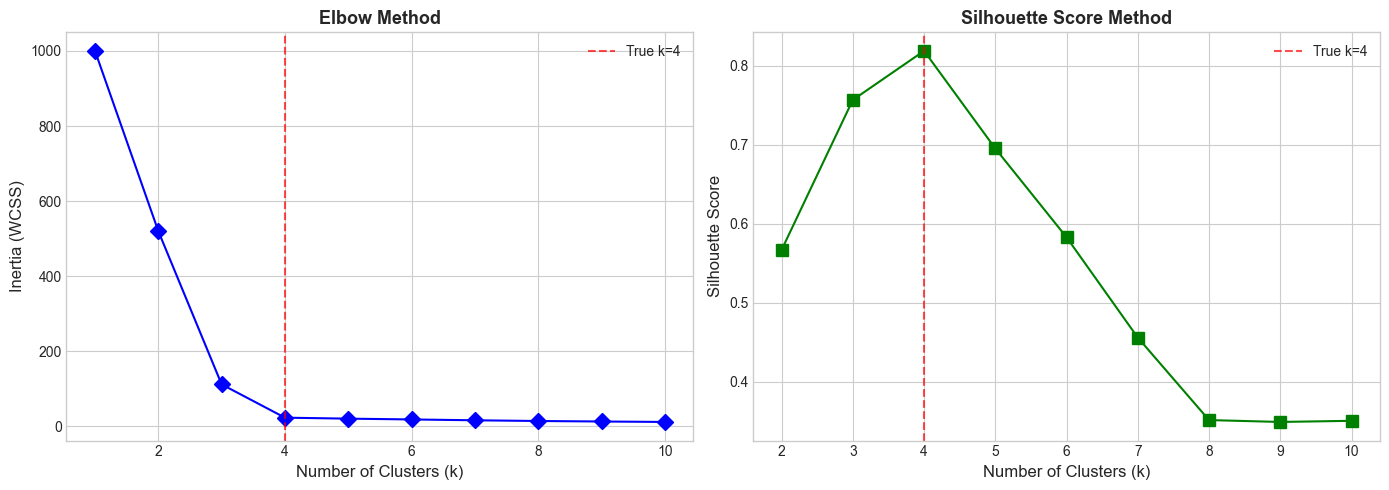

Best k by Silhouette: 4
Best Silhouette Score: 0.8187


In [6]:
# Generate dataset
X_blobs, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.9, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_blobs)

# ---- Elbow Method ----
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# ---- Silhouette Scores ----
silhouette_scores = []
K_range_sil = range(2, 11)  # Silhouette needs at least 2 clusters

for k in K_range_sil:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(K_range), inertias, 'bD-', markersize=8)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='True k=4')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].legend()

# Silhouette plot
axes[1].plot(list(K_range_sil), silhouette_scores, 'gs-', markersize=8)
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='True k=4')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score Method', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

best_k = list(K_range_sil)[np.argmax(silhouette_scores)]
print(f'Best k by Silhouette: {best_k}')
print(f'Best Silhouette Score: {max(silhouette_scores):.4f}')

## 📊 1.5 Silhouette Plot — Deep Dive

The **silhouette plot** shows how well each point fits its cluster.

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

- $a(i)$: mean distance to points in **same cluster** (cohesion)
- $b(i)$: mean distance to points in **nearest other cluster** (separation)
- Range: $[-1, 1]$. Closer to **1 = well-clustered**, **0 = boundary**, **-1 = misclassified**

k=2: Avg Silhouette = 0.5669
k=4: Avg Silhouette = 0.8187
k=6: Avg Silhouette = 0.5830


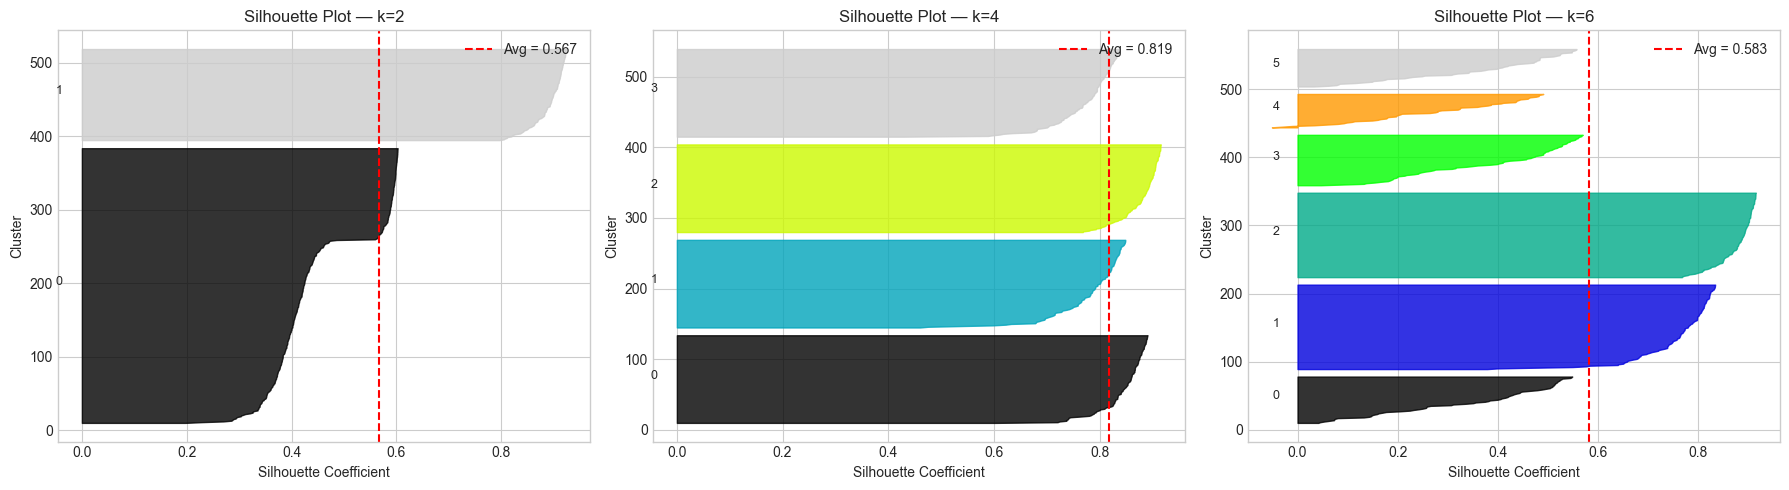

In [7]:
def plot_silhouette(X, k, ax=None):
    """Plot silhouette diagram for a given k."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    
    sil_vals = silhouette_samples(X, labels)
    avg_score = sil_vals.mean()
    
    y_lower = 10
    colors = cm.nipy_spectral(np.linspace(0, 1, k))
    
    for i in range(k):
        cluster_sil_vals = np.sort(sil_vals[labels == i])
        size = len(cluster_sil_vals)
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_vals,
                         facecolor=colors[i], edgecolor=colors[i], alpha=0.8)
        ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=9)
        y_lower = y_upper + 10
    
    ax.axvline(x=avg_score, color='red', linestyle='--', label=f'Avg = {avg_score:.3f}')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.set_title(f'Silhouette Plot — k={k}')
    ax.legend(loc='upper right')
    return avg_score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, k in enumerate([2, 4, 6]):
    score = plot_silhouette(X_scaled, k, ax=axes[idx])
    print(f'k={k}: Avg Silhouette = {score:.4f}')

plt.tight_layout()
plt.show()

## ✏️ Exercise 1.2 — Choose the Right K

**Questions:**
1. Looking at the Elbow plot, where does the 'elbow' appear? Why is it not always obvious?
2. Which k gives the best Silhouette score? Does it match the true number of clusters?
3. In the Silhouette plot for k=4, are all clusters roughly equal in width? What would unequal widths suggest?
4. What is a limitation of using ONLY inertia to choose k?

In [ ]:
# YOUR ANSWERS HERE (as comments or print statements)

# Q1:

# Q2:

# Q3:

# Q4:


## ⚠️ 1.6 K-Means Limitations — Where It Fails

In [ ]:
# Generate challenging datasets
np.random.seed(42)
n = 300

X_moons, _ = make_moons(n_samples=n, noise=0.1, random_state=42)
X_circles, _ = make_circles(n_samples=n, factor=0.4, noise=0.05, random_state=42)

# Elongated clusters (different variances)
X_elong = np.vstack([
    np.random.randn(n//3, 2) @ [[2, 0], [0, 0.2]] + [3, 0],
    np.random.randn(n//3, 2) @ [[0.2, 0], [0, 2]] + [-3, 0],
    np.random.randn(n//3, 2) * 0.5 + [0, 3]
])

# Different sizes
X_sizes = np.vstack([
    np.random.randn(200, 2) * 0.3 + [0, 0],
    np.random.randn(50, 2) * 0.3 + [5, 5],
    np.random.randn(50, 2) * 0.3 + [-5, 5]
])

datasets = [
    (X_moons, 'Moons (non-convex)', 2),
    (X_circles, 'Circles (nested)', 2),
    (StandardScaler().fit_transform(X_elong), 'Elongated Clusters', 3),
    (StandardScaler().fit_transform(X_sizes), 'Different Sizes', 3),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for idx, (X, title, k) in enumerate(datasets):
    # True labels (first column)
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    
    # Original data
    axes[0, idx].scatter(X[:, 0], X[:, 1], c='steelblue', alpha=0.5, s=20)
    axes[0, idx].set_title(f'Original: {title}', fontsize=10)
    axes[0, idx].set_xticks([]); axes[0, idx].set_yticks([])
    
    # K-Means result
    cmap = plt.cm.tab10
    axes[1, idx].scatter(X[:, 0], X[:, 1], c=labels, cmap=cmap, alpha=0.5, s=20)
    axes[1, idx].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                         c='black', marker='X', s=150, zorder=5)
    sil = silhouette_score(X, labels)
    axes[1, idx].set_title(f'K-Means k={k}\nSilhouette={sil:.3f}', fontsize=10)
    axes[1, idx].set_xticks([]); axes[1, idx].set_yticks([])

axes[0, 0].set_ylabel('Original Data', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('K-Means Result', fontsize=12, fontweight='bold')
plt.suptitle('K-Means Struggles With These Shapes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# PART 2: DBSCAN
---

## 📖 2.1 Theory & Intuition

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) groups points that are closely packed together and marks outliers as noise.

### Core Concepts

DBSCAN uses **two hyperparameters**:
- **`eps` (ε):** The maximum radius of a neighborhood
- **`min_samples`:** Minimum points within ε to form a dense region

### Point Classification

| Type | Definition |
|------|------------|
| **Core Point** | Has ≥ `min_samples` points within ε (including itself) |
| **Border Point** | Within ε of a core point but has < `min_samples` neighbors |
| **Noise Point** | Neither core nor border — an outlier |

### The Algorithm

```
For each unvisited point P:
    Mark P as visited
    Find all neighbors within ε
    
    If |neighbors| < min_samples:
        Mark P as NOISE (temporarily)
    Else:
        Create new cluster C
        Add P to C
        For each neighbor Q:
            If Q is unvisited:
                Mark Q as visited
                Find Q's neighbors
                If |Q's neighbors| >= min_samples:
                    Add Q's neighbors to seed list
            If Q not in any cluster:
                Add Q to cluster C
```

### ✅ DBSCAN Advantages
- Finds **arbitrary-shaped** clusters
- Automatically detects **outliers/noise**
- Does **not** require specifying k

### ⚠️ DBSCAN Limitations
- Struggles with **varying density** clusters
- Sensitive to `eps` and `min_samples`
- Poor on **high-dimensional** data

## 🛠️ 2.2 DBSCAN from Scratch

In [ ]:
class DBSCANScratch:
    """
    DBSCAN implemented from scratch.
    
    Parameters
    ----------
    eps : float
        Maximum distance between two points to be neighbors
    min_samples : int
        Minimum points to form a dense region (core point)
    """
    
    NOISE = -1
    UNVISITED = -2
    
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None
    
    def _get_neighbors(self, X, point_idx):
        """Return indices of all points within eps distance."""
        neighbors = []
        for i, point in enumerate(X):
            dist = np.linalg.norm(X[point_idx] - point)
            if dist <= self.eps:
                neighbors.append(i)
        return neighbors
    
    def _expand_cluster(self, X, labels, point_idx, neighbors, cluster_id):
        """Expand a cluster by exploring density-reachable points."""
        labels[point_idx] = cluster_id
        seed_set = list(neighbors)
        
        i = 0
        while i < len(seed_set):
            q = seed_set[i]
            
            if labels[q] == self.NOISE:
                labels[q] = cluster_id  # Noise becomes border point
            
            if labels[q] == self.UNVISITED:
                labels[q] = cluster_id
                q_neighbors = self._get_neighbors(X, q)
                
                if len(q_neighbors) >= self.min_samples:
                    # q is a core point — expand further
                    seed_set.extend(q_neighbors)
            
            i += 1
    
    def fit(self, X):
        """Fit DBSCAN to dataset X."""
        n = len(X)
        labels = np.full(n, self.UNVISITED)
        cluster_id = 0
        
        for idx in range(n):
            if labels[idx] != self.UNVISITED:
                continue  # Already processed
            
            neighbors = self._get_neighbors(X, idx)
            
            if len(neighbors) < self.min_samples:
                labels[idx] = self.NOISE  # Mark as noise
            else:
                # Core point — start new cluster
                self._expand_cluster(X, labels, idx, neighbors, cluster_id)
                cluster_id += 1
        
        self.labels_ = labels
        self.n_clusters_ = cluster_id
        self.n_noise_ = np.sum(labels == self.NOISE)
        return self
    
    def fit_predict(self, X):
        return self.fit(X).labels_

print('✅ DBSCANScratch class defined!')

In [ ]:
# Test on moons dataset
X_test_db, _ = make_moons(n_samples=200, noise=0.05, random_state=42)
scaler_db = StandardScaler()
X_test_db_scaled = scaler_db.fit_transform(X_test_db)

print('Running DBSCAN from scratch (may take a moment)...')
db_scratch = DBSCANScratch(eps=0.3, min_samples=5)
db_scratch.fit(X_test_db_scaled)

print(f'Clusters found: {db_scratch.n_clusters_}')
print(f'Noise points: {db_scratch.n_noise_}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scratch result
labels_s = db_scratch.labels_
noise_mask = labels_s == -1
axes[0].scatter(X_test_db_scaled[~noise_mask, 0], X_test_db_scaled[~noise_mask, 1],
                c=labels_s[~noise_mask], cmap='tab10', s=30, alpha=0.8)
axes[0].scatter(X_test_db_scaled[noise_mask, 0], X_test_db_scaled[noise_mask, 1],
                c='red', marker='x', s=80, label='Noise', zorder=5)
axes[0].set_title('DBSCAN from Scratch', fontsize=13)
axes[0].legend()

# Sklearn result for comparison
db_sk = DBSCAN(eps=0.3, min_samples=5)
labels_sk = db_sk.fit_predict(X_test_db_scaled)
noise_sk = labels_sk == -1
axes[1].scatter(X_test_db_scaled[~noise_sk, 0], X_test_db_scaled[~noise_sk, 1],
                c=labels_sk[~noise_sk], cmap='tab10', s=30, alpha=0.8)
axes[1].scatter(X_test_db_scaled[noise_sk, 0], X_test_db_scaled[noise_sk, 1],
                c='red', marker='x', s=80, label='Noise', zorder=5)
axes[1].set_title('DBSCAN (scikit-learn)', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

match = np.sum(labels_s == labels_sk)
print(f'Agreement between scratch and sklearn: {match}/{len(labels_s)}')

## 📊 2.3 Visualizing Core, Border, and Noise Points

In [ ]:
def visualize_dbscan_point_types(X, eps=0.5, min_samples=5):
    """Visualize core, border, and noise points separately."""
    db = DBSCAN(eps=eps, min_samples=min_samples)
    db.fit(X)
    
    core_mask = np.zeros(len(X), dtype=bool)
    core_mask[db.core_sample_indices_] = True
    noise_mask = db.labels_ == -1
    border_mask = ~core_mask & ~noise_mask
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Point types
    axes[0].scatter(X[core_mask, 0], X[core_mask, 1], 
                    c='steelblue', s=50, alpha=0.8, label=f'Core ({core_mask.sum()})')
    axes[0].scatter(X[border_mask, 0], X[border_mask, 1], 
                    c='orange', s=50, alpha=0.8, marker='s', label=f'Border ({border_mask.sum()})')
    axes[0].scatter(X[noise_mask, 0], X[noise_mask, 1], 
                    c='red', s=80, marker='x', linewidths=2, label=f'Noise ({noise_mask.sum()})')
    
    # Draw eps circles around a few core points
    for i in db.core_sample_indices_[:3]:
        circle = plt.Circle(X[i], eps, color='steelblue', fill=False, alpha=0.3, linestyle='--')
        axes[0].add_patch(circle)
    
    axes[0].set_title(f'Point Types (eps={eps}, min_samples={min_samples})\nDashed circles = ε neighborhoods', fontsize=11)
    axes[0].legend(fontsize=10)
    axes[0].set_aspect('equal')
    
    # Final clusters
    unique_labels = set(db.labels_) - {-1}
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))
    for idx, label in enumerate(unique_labels):
        mask = db.labels_ == label
        axes[1].scatter(X[mask, 0], X[mask, 1], c=[colors[idx]], s=40, alpha=0.7, label=f'Cluster {label}')
    axes[1].scatter(X[noise_mask, 0], X[noise_mask, 1], c='red', marker='x', s=80, 
                    linewidths=2, label='Noise', zorder=5)
    axes[1].set_title(f'Final Clusters — {len(unique_labels)} found', fontsize=11)
    axes[1].legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return db

# Add some noise to moons
X_noisy_moons, _ = make_moons(n_samples=300, noise=0.1, random_state=0)
X_noisy_moons_scaled = StandardScaler().fit_transform(X_noisy_moons)
db_result = visualize_dbscan_point_types(X_noisy_moons_scaled, eps=0.3, min_samples=5)

## 🔧 2.4 Choosing eps with the K-Distance Plot

The **K-distance plot** (knee method) helps choose `eps` automatically:
1. Compute the distance to the k-th nearest neighbor for each point
2. Sort in ascending order and plot
3. Look for the **"knee"** in the curve — this is a good `eps` value

In [ ]:
def plot_k_distance(X, min_samples=5):
    """Plot the k-distance curve to estimate eps."""
    # Fit k-nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X)
    distances, _ = nbrs.kneighbors(X)
    
    # Take the distance to the min_samples-th nearest neighbor
    kth_distances = np.sort(distances[:, -1])[::-1]
    
    plt.figure(figsize=(9, 5))
    plt.plot(kth_distances, 'b-', linewidth=2)
    plt.xlabel('Points (sorted by distance)', fontsize=12)
    plt.ylabel(f'{min_samples}-NN Distance', fontsize=12)
    plt.title(f'K-Distance Plot (k={min_samples})\nLook for the "knee" to choose eps', fontsize=13)
    
    # Add some candidate eps lines
    for eps_candidate, color in [(0.15, 'green'), (0.3, 'orange'), (0.5, 'red')]:
        plt.axhline(y=eps_candidate, color=color, linestyle='--', alpha=0.7, 
                    label=f'eps = {eps_candidate}')
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_k_distance(X_noisy_moons_scaled, min_samples=5)

## 🔍 2.5 Effect of eps and min_samples

In [ ]:
# Grid search over eps and min_samples
X_grid, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
X_grid_scaled = StandardScaler().fit_transform(X_grid)

eps_values = [0.1, 0.3, 0.6]
min_samples_values = [3, 5, 10]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for row, min_samp in enumerate(min_samples_values):
    for col, eps in enumerate(eps_values):
        ax = axes[row, col]
        db = DBSCAN(eps=eps, min_samples=min_samp)
        labels = db.fit_predict(X_grid_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        noise_mask = labels == -1
        
        if n_clusters > 0:
            ax.scatter(X_grid_scaled[~noise_mask, 0], X_grid_scaled[~noise_mask, 1],
                       c=labels[~noise_mask], cmap='tab10', s=20, alpha=0.8)
        else:
            ax.scatter(X_grid_scaled[:, 0], X_grid_scaled[:, 1], c='gray', s=20, alpha=0.5)
        
        ax.scatter(X_grid_scaled[noise_mask, 0], X_grid_scaled[noise_mask, 1],
                   c='red', marker='x', s=50, linewidths=1.5)
        
        ax.set_title(f'eps={eps}, min_s={min_samp}\n{n_clusters} clusters, {n_noise} noise', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('DBSCAN: Effect of eps and min_samples', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## ✏️ Exercise 2.1 — Tune DBSCAN Parameters

**Task:** Given the dataset below, find the best `eps` and `min_samples` that correctly finds **3 clusters** and minimizes noise points.

Use the K-distance plot and the grid above as guidance. Fill in your answer.

In [ ]:
# Dataset for tuning exercise
X_exercise, y_exercise = make_blobs(n_samples=400, centers=3, cluster_std=0.5, random_state=99)
# Add some outliers
outliers = np.random.uniform(low=-6, high=6, size=(20, 2))
X_exercise = np.vstack([X_exercise, outliers])
X_exercise_scaled = StandardScaler().fit_transform(X_exercise)

# Step 1: Use k-distance plot to estimate eps
plot_k_distance(X_exercise_scaled, min_samples=5)

# Step 2: Fill in your chosen parameters
best_eps = None         # TODO: Set your eps
best_min_samples = None # TODO: Set your min_samples

# Step 3: Fit and visualize
if best_eps is not None:
    db_ex = DBSCAN(eps=best_eps, min_samples=best_min_samples)
    labels_ex = db_ex.fit_predict(X_exercise_scaled)
    
    n_cl = len(set(labels_ex)) - (1 if -1 in labels_ex else 0)
    n_no = np.sum(labels_ex == -1)
    
    plt.figure(figsize=(7, 5))
    noise_m = labels_ex == -1
    plt.scatter(X_exercise_scaled[~noise_m, 0], X_exercise_scaled[~noise_m, 1],
                c=labels_ex[~noise_m], cmap='tab10', s=30, alpha=0.8)
    plt.scatter(X_exercise_scaled[noise_m, 0], X_exercise_scaled[noise_m, 1],
                c='red', marker='x', s=80, linewidths=2, label='Noise')
    plt.title(f'Your DBSCAN: {n_cl} clusters, {n_no} noise pts')
    plt.legend()
    plt.show()
    
    print(f'Clusters found: {n_cl} (target: 3)')
    print(f'Noise points: {n_no}')
else:
    print('👆 Set best_eps and best_min_samples above!')

---
# PART 3: HEAD-TO-HEAD COMPARISON
---

## 3.1 K-Means vs DBSCAN on Multiple Datasets

In [ ]:
np.random.seed(42)
n = 300

# Create diverse datasets
X_blobs3, _ = make_blobs(n_samples=n, centers=3, cluster_std=0.7, random_state=42)
X_moons2, _ = make_moons(n_samples=n, noise=0.07, random_state=42)
X_circles2, _ = make_circles(n_samples=n, factor=0.4, noise=0.04, random_state=42)

# Dataset with outliers
X_outliers, _ = make_blobs(n_samples=n, centers=3, cluster_std=0.5, random_state=0)
X_outliers = np.vstack([X_outliers, np.random.uniform(-8, 8, size=(15, 2))])

datasets_compare = [
    (StandardScaler().fit_transform(X_blobs3),   'Blobs',     3, 0.4, 5),
    (StandardScaler().fit_transform(X_moons2),   'Moons',     2, 0.25, 5),
    (StandardScaler().fit_transform(X_circles2), 'Circles',   2, 0.25, 5),
    (StandardScaler().fit_transform(X_outliers), 'Outliers',  3, 0.4, 5),
]

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
row_labels = ['Original', 'K-Means', 'DBSCAN']

for col, (X, name, k, eps, min_s) in enumerate(datasets_compare):
    # Original
    axes[0, col].scatter(X[:, 0], X[:, 1], c='steelblue', s=15, alpha=0.7)
    axes[0, col].set_title(name, fontsize=12, fontweight='bold')
    
    # K-Means
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km_labels = km.fit_predict(X)
    km_sil = silhouette_score(X, km_labels) if len(set(km_labels)) > 1 else 0
    axes[1, col].scatter(X[:, 0], X[:, 1], c=km_labels, cmap='tab10', s=15, alpha=0.7)
    axes[1, col].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                         c='black', marker='X', s=150, zorder=5)
    axes[1, col].set_title(f'Sil={km_sil:.3f}', fontsize=10)
    
    # DBSCAN
    db = DBSCAN(eps=eps, min_samples=min_s)
    db_labels = db.fit_predict(X)
    noise_m = db_labels == -1
    n_cl = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    
    db_sil = silhouette_score(X[~noise_m], db_labels[~noise_m]) if (n_cl > 1 and np.sum(~noise_m) > 1) else 0
    
    axes[2, col].scatter(X[~noise_m, 0], X[~noise_m, 1], c=db_labels[~noise_m], cmap='tab10', s=15, alpha=0.7)
    axes[2, col].scatter(X[noise_m, 0], X[noise_m, 1], c='red', marker='x', s=50, linewidths=1.5)
    axes[2, col].set_title(f'{n_cl} clusters, {np.sum(noise_m)} noise\nSil={db_sil:.3f}', fontsize=10)

for row_idx, label in enumerate(row_labels):
    axes[row_idx, 0].set_ylabel(label, fontsize=12, fontweight='bold')

for ax in axes.flatten():
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('K-Means vs DBSCAN — Side by Side', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3.2 Evaluation Metrics Deep Dive

In [ ]:
# Compare multiple evaluation metrics
X_eval, y_eval_true = make_blobs(n_samples=400, centers=4, cluster_std=0.8, random_state=42)
X_eval_scaled = StandardScaler().fit_transform(X_eval)

results = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_eval_scaled)
    
    sil = silhouette_score(X_eval_scaled, labels)
    db_idx = davies_bouldin_score(X_eval_scaled, labels)
    ch = calinski_harabasz_score(X_eval_scaled, labels)
    ari = adjusted_rand_score(y_eval_true, labels)  # Needs true labels
    
    results.append({'k': k, 'Silhouette ↑': sil, 'Davies-Bouldin ↓': db_idx,
                    'Calinski-Harabasz ↑': ch, 'ARI ↑': ari})

df_results = pd.DataFrame(results).set_index('k')
print('\n📊 Clustering Metrics by k:')
print(df_results.round(4).to_string())

# Plot all metrics
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metrics = ['Silhouette ↑', 'Davies-Bouldin ↓', 'Calinski-Harabasz ↑', 'ARI ↑']
colors_m = ['blue', 'red', 'green', 'purple']

for ax, metric, color in zip(axes.flatten(), metrics, colors_m):
    ax.plot(df_results.index, df_results[metric], f'{color[0]}o-', linewidth=2, markersize=7)
    ax.axvline(x=4, color='gray', linestyle='--', alpha=0.7, label='True k=4')
    ax.set_xlabel('k'); ax.set_ylabel(metric)
    ax.set_title(metric, fontsize=12)
    ax.legend()

plt.suptitle('Clustering Evaluation Metrics vs k', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 📖 Metric Summary

| Metric | Range | Goal | Needs True Labels? |
|--------|-------|------|--------------------|
| **Silhouette Score** | [-1, 1] | Higher is better | ❌ No |
| **Davies-Bouldin Index** | [0, ∞) | Lower is better | ❌ No |
| **Calinski-Harabasz** | [0, ∞) | Higher is better | ❌ No |
| **Adjusted Rand Index** | [-1, 1] | 1 = perfect match | ✅ Yes |

> **Note:** In real applications, you usually don't have true labels. Use intrinsic metrics (Silhouette, DBI, CH) together.

---
# PART 4: REAL-WORLD APPLICATION
---

## 4.1 Customer Segmentation with K-Means

In [ ]:
# Generate synthetic customer data
np.random.seed(42)
n_customers = 500

# Simulate different customer segments
segments = {
    'Budget Shoppers':    {'age': (35, 10), 'income': (30000, 8000),  'spending': (1500, 400),  'n': 150},
    'Young Spenders':     {'age': (25, 5),  'income': (45000, 10000), 'spending': (4000, 800),  'n': 100},
    'Affluent Seniors':   {'age': (55, 8),  'income': (90000, 15000), 'spending': (8000, 1500), 'n': 100},
    'Mid-tier Families':  {'age': (42, 8),  'income': (60000, 12000), 'spending': (5000, 1000), 'n': 150},
}

customer_data = []
for segment, params in segments.items():
    n = params['n']
    customer_data.append(pd.DataFrame({
        'age':             np.random.normal(*params['age'], n).clip(18, 80),
        'annual_income':   np.random.normal(*params['income'], n).clip(15000, 150000),
        'annual_spending': np.random.normal(*params['spending'], n).clip(500, 15000),
        'true_segment':    segment
    }))

df_customers = pd.concat(customer_data, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print('Customer Dataset:')
print(df_customers.describe().round(1))

In [ ]:
# Prepare features
features = ['age', 'annual_income', 'annual_spending']
X_customers = df_customers[features].values
X_customers_scaled = StandardScaler().fit_transform(X_customers)

# Find optimal k
inertias_cust = []
sil_scores_cust = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_customers_scaled)
    inertias_cust.append(km.inertia_)
    sil_scores_cust.append(silhouette_score(X_customers_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(range(2, 10), inertias_cust, 'bo-', markersize=7)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='True k=4')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Customer Data'); axes[0].legend()

axes[1].plot(range(2, 10), sil_scores_cust, 'gs-', markersize=7)
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='True k=4')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette — Customer Data'); axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Fit K-Means with k=4
km_final = KMeans(n_clusters=4, init='k-means++', n_init=20, random_state=42)
df_customers['cluster'] = km_final.fit_predict(X_customers_scaled)

# Segment profiles
print('\n📊 Cluster Profiles:')
profile = df_customers.groupby('cluster')[features].mean().round(0)
profile['size'] = df_customers.groupby('cluster').size()
print(profile)

# Visualize in 3D-style (2D projections)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [('age', 'annual_income'), ('annual_income', 'annual_spending'), ('age', 'annual_spending')]
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for ax, (fx, fy) in zip(axes, pairs):
    for cl in range(4):
        mask = df_customers['cluster'] == cl
        ax.scatter(df_customers.loc[mask, fx], df_customers.loc[mask, fy],
                   label=f'Cluster {cl}', alpha=0.5, s=20)
    ax.set_xlabel(fx.replace('_', ' ').title())
    ax.set_ylabel(fy.replace('_', ' ').title())
    ax.legend(fontsize=8)

plt.suptitle('Customer Segments — K-Means (k=4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.2 Anomaly Detection with DBSCAN

In [ ]:
# Simulate network traffic (normal + anomalous)
np.random.seed(42)

# Normal traffic patterns
normal_traffic = np.vstack([
    np.random.normal([100, 50], [15, 8], size=(300, 2)),   # Web browsing
    np.random.normal([20, 200], [5, 20], size=(200, 2)),   # File downloads
    np.random.normal([50, 10], [8, 3], size=(150, 2)),     # Email traffic
])

# Anomalies (potential intrusions/DDoS)
anomalies = np.vstack([
    np.random.uniform([200, 300], [400, 500], size=(15, 2)),  # High volume anomaly
    np.random.normal([0, 0], [2, 2], size=(10, 2)),           # Near-zero anomaly
])

X_traffic = np.vstack([normal_traffic, anomalies])
X_traffic_scaled = StandardScaler().fit_transform(X_traffic)
true_anomaly = np.array([False] * len(normal_traffic) + [True] * len(anomalies))

# Apply DBSCAN
db_traffic = DBSCAN(eps=0.4, min_samples=10)
traffic_labels = db_traffic.fit_predict(X_traffic_scaled)
detected_anomalies = traffic_labels == -1

# Evaluation
true_pos = np.sum(detected_anomalies & true_anomaly)
false_pos = np.sum(detected_anomalies & ~true_anomaly)
false_neg = np.sum(~detected_anomalies & true_anomaly)

precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0

print(f'True Positives (correctly detected anomalies): {true_pos}')
print(f'False Positives (normal flagged as anomaly):  {false_pos}')
print(f'False Negatives (anomalies missed):           {false_neg}')
print(f'Precision: {precision:.3f}')
print(f'Recall:    {recall:.3f}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_traffic_scaled[~true_anomaly, 0], X_traffic_scaled[~true_anomaly, 1],
                c='steelblue', s=15, alpha=0.6, label='Normal')
axes[0].scatter(X_traffic_scaled[true_anomaly, 0], X_traffic_scaled[true_anomaly, 1],
                c='red', s=80, marker='*', label='True Anomaly', zorder=5)
axes[0].set_title('Ground Truth', fontsize=12); axes[0].legend()

axes[1].scatter(X_traffic_scaled[~detected_anomalies, 0], X_traffic_scaled[~detected_anomalies, 1],
                c=traffic_labels[~detected_anomalies], cmap='tab10', s=15, alpha=0.6)
axes[1].scatter(X_traffic_scaled[detected_anomalies, 0], X_traffic_scaled[detected_anomalies, 1],
                c='red', marker='x', s=80, linewidths=2, label=f'Detected Anomaly ({detected_anomalies.sum()})', zorder=5)
axes[1].set_title(f'DBSCAN Detection (Precision={precision:.2f}, Recall={recall:.2f})', fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
# PART 5: ADVANCED TOPICS
---

## 5.1 Mini-Batch K-Means for Large Datasets

In [ ]:
from sklearn.cluster import MiniBatchKMeans
import time

# Large dataset
X_large, _ = make_blobs(n_samples=50000, centers=5, cluster_std=1.5, random_state=42)
X_large_scaled = StandardScaler().fit_transform(X_large)

# Standard K-Means timing
start = time.time()
km_full = KMeans(n_clusters=5, n_init=3, random_state=42)
km_full.fit(X_large_scaled)
t_full = time.time() - start

# Mini-Batch K-Means timing
start = time.time()
km_mini = MiniBatchKMeans(n_clusters=5, batch_size=1000, n_init=3, random_state=42)
km_mini.fit(X_large_scaled)
t_mini = time.time() - start

sil_full = silhouette_score(X_large_scaled, km_full.labels_, sample_size=5000)
sil_mini = silhouette_score(X_large_scaled, km_mini.labels_, sample_size=5000)

print(f'{'Method':<20} {'Time (s)':<12} {'Inertia':<15} {'Silhouette'}')
print('-' * 60)
print(f'{'Standard K-Means':<20} {t_full:<12.3f} {km_full.inertia_:<15.0f} {sil_full:.4f}')
print(f'{'Mini-Batch K-Means':<20} {t_mini:<12.3f} {km_mini.inertia_:<15.0f} {sil_mini:.4f}')
print(f'\n⚡ Speedup: {t_full/t_mini:.1f}x faster with Mini-Batch')

## 5.2 Effect of Feature Scaling on Clustering

In [ ]:
# Demonstrate importance of scaling
np.random.seed(42)

# Generate data with very different scales
raw_data = np.column_stack([
    np.concatenate([np.random.normal(100, 5, 100), np.random.normal(200, 5, 100), np.random.normal(150, 5, 100)]),
    np.concatenate([np.random.normal(1, 0.1, 100), np.random.normal(1, 0.1, 100), np.random.normal(10, 0.1, 100)])
])

scaled_data = StandardScaler().fit_transform(raw_data)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, title in [(axes[0], raw_data, 'Unscaled Data'), (axes[1], scaled_data, 'Scaled Data')]:
    km = KMeans(n_clusters=3, n_init=10, random_state=42)
    labels = km.fit_predict(data)
    sil = silhouette_score(data, labels)
    ax.scatter(data[:, 0], data[:, 1], c=labels, cmap='tab10', s=30, alpha=0.7)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], c='black', marker='X', s=200)
    ax.set_title(f'{title}\nSilhouette = {sil:.4f}', fontsize=12)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

plt.suptitle('🚨 Always Scale Your Features Before Clustering!', fontsize=13, fontweight='bold', color='red')
plt.tight_layout()
plt.show()

---
# PART 6: COMPREHENSIVE EXERCISES
---

## ✏️ Exercise 6.1 — Full Pipeline Challenge

**Task:** You are given a mystery dataset. Your job is to:
1. Explore the data
2. Preprocess and scale
3. Apply both K-Means and DBSCAN
4. Compare results using at least 2 metrics
5. Choose the better algorithm and justify your choice

In [1]:
# Mystery dataset
np.random.seed(7)
n = 600

theta = np.linspace(0, 2 * np.pi, n // 3)
r1, r2, r3 = 3, 6, 9

ring1 = np.column_stack([r1 * np.cos(theta) + np.random.normal(0, 0.2, len(theta)),
                          r1 * np.sin(theta) + np.random.normal(0, 0.2, len(theta))])
ring2 = np.column_stack([r2 * np.cos(theta) + np.random.normal(0, 0.25, len(theta)),
                          r2 * np.sin(theta) + np.random.normal(0, 0.25, len(theta))])
ring3 = np.column_stack([r3 * np.cos(theta) + np.random.normal(0, 0.3, len(theta)),
                          r3 * np.sin(theta) + np.random.normal(0, 0.3, len(theta))])

X_mystery = np.vstack([ring1, ring2, ring3])

# Add some noise points
noise_pts = np.random.uniform(-11, 11, size=(20, 2))
X_mystery = np.vstack([X_mystery, noise_pts])

plt.figure(figsize=(7, 7))
plt.scatter(X_mystery[:, 0], X_mystery[:, 1], c='steelblue', s=15, alpha=0.7)
plt.title('Mystery Dataset — What clustering approach works here?', fontsize=12)
plt.axis('equal')
plt.show()

print(f'Dataset shape: {X_mystery.shape}')

NameError: name 'np' is not defined

In [ ]:
# ============================================================
# YOUR SOLUTION HERE
# ============================================================

# Step 1: Scale the data
# X_mystery_scaled = ...

# Step 2: Apply K-Means (choose k using elbow / silhouette)
# km_mystery = ...

# Step 3: Apply DBSCAN (choose eps using k-distance plot)
# db_mystery = ...

# Step 4: Compute evaluation metrics

# Step 5: Visualize both results side by side

# Step 6: Write your conclusion below
# CONCLUSION:
# The better algorithm is ________ because ______________________

print('Complete the exercise above!')

## ✏️ Exercise 6.2 — Algorithm Selection Quiz

For each scenario below, decide whether **K-Means** or **DBSCAN** is more appropriate. Justify each answer.

In [ ]:
scenarios = [
    ("A", "You have customer purchase data and want to find exactly 5 market segments for a marketing campaign."),
    ("B", "You are analyzing GPS trajectories of vehicles and want to find regions of activity. Some vehicles may stop anywhere."),
    ("C", "You have satellite images of land use and want to categorize land into urban/rural/forest/water (4 types)."),
    ("D", "You have 1 million transaction records and need to identify fraudulent transactions (rare outliers)."),
    ("E", "You need to compress an image by reducing the number of distinct colors to 16."),
    ("F", "You have social media posts and want to find discussion topics. The number of topics is unknown."),
]

for letter, scenario in scenarios:
    print(f'Scenario {letter}: {scenario}')
    print(f'  → My answer: [TODO: K-Means / DBSCAN] because [TODO: reasoning]')
    print()

---
# PART 7: SUMMARY & CHEAT SHEET
---

In [ ]:
summary = """
╔══════════════════════════════════════════════════════════════════════════════╗
║                    K-MEANS vs DBSCAN — QUICK REFERENCE                     ║
╠═══════════════════════╦════════════════════════╦═══════════════════════════╣
║ Property              ║ K-Means                ║ DBSCAN                    ║
╠═══════════════════════╬════════════════════════╬═══════════════════════════╣
║ Cluster Shape         ║ Convex / spherical     ║ Arbitrary                 ║
║ Specify k?            ║ Yes (required)         ║ No                        ║
║ Handles Outliers?     ║ No (pulls centroids)   ║ Yes (marked as noise)     ║
║ Parameters            ║ k                      ║ eps, min_samples          ║
║ Scalability           ║ Good (O(nk))           ║ Medium (O(n log n))       ║
║ High Dimensions       ║ Reasonable             ║ Poor (curse of dim.)      ║
║ Varying Density       ║ Mediocre               ║ Poor                      ║
║ Use When...           ║ Known k, spherical     ║ Unknown k, arbitrary      ║
║                       ║ clusters, large data   ║ shapes, with outliers     ║
╠═══════════════════════╩════════════════════════╩═══════════════════════════╣
║ EVALUATION METRICS                                                         ║
║  • Silhouette Score   → [-1, 1],  higher = better (no true labels needed) ║
║  • Davies-Bouldin     → [0, ∞),   lower  = better (no true labels needed) ║
║  • Calinski-Harabasz  → [0, ∞),   higher = better (no true labels needed) ║
║  • Adjusted Rand Idx  → [-1, 1],  higher = better (true labels REQUIRED)  ║
╠════════════════════════════════════════════════════════════════════════════╣
║ KEY REMINDERS                                                              ║
║  ✅ ALWAYS scale features before clustering                                ║
║  ✅ Use Elbow + Silhouette together to choose k                            ║
║  ✅ Use K-distance plot to estimate eps for DBSCAN                         ║
║  ✅ Use K-Means++ initialization (default in sklearn)                      ║
║  ⚠️  Neither algorithm works well on all datasets                         ║
║  ⚠️  Always visualize your clusters!                                       ║
╚════════════════════════════════════════════════════════════════════════════╝
"""
print(summary)

In [ ]:
# Sklearn Quick Reference
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SKLEARN QUICK REFERENCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. Scale your data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2a. K-Means
km = KMeans(
    n_clusters=4,       # Required: number of clusters
    init='k-means++',   # Better initialization
    n_init=10,          # Run 10 times, keep best
    max_iter=300,
    random_state=42
)
labels_km = km.fit_predict(X_scaled)
print(km.inertia_)              # WCSS
print(km.cluster_centers_)     # Centroids

# 2b. DBSCAN
db = DBSCAN(
    eps=0.5,            # Neighborhood radius
    min_samples=5,      # Min points for core
    metric='euclidean'
)
labels_db = db.fit_predict(X_scaled)
print(db.labels_)               # -1 = noise
print(db.core_sample_indices_)  # Core point indices

# 3. Evaluate
from sklearn.metrics import silhouette_score
sil = silhouette_score(X_scaled, labels_km)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

---

## 🎓 Congratulations! You've completed the workbook.

### What you've covered:
- ✅ K-Means algorithm from scratch (with intuition)
- ✅ DBSCAN algorithm from scratch (with intuition)
- ✅ Elbow Method, Silhouette Analysis
- ✅ K-distance plot for DBSCAN tuning
- ✅ Evaluation metrics (Silhouette, DBI, CH, ARI)
- ✅ Real-world applications (segmentation, anomaly detection)
- ✅ Feature scaling importance
- ✅ Algorithm selection heuristics

### 📚 Further Reading
- [Scikit-learn Clustering Guide](https://scikit-learn.org/stable/modules/clustering.html)
- Ester et al. (1996) — Original DBSCAN paper
- Arthur & Vassilvitskii (2007) — K-Means++ paper

---
*Workbook created for unsupervised machine learning education.*